In [1]:
# Class imbalance refers to a situation in which the existing classes in a dataset aren't equally represented. Earlier we discussed a fraud detection scenario in which a large number of credit card transactions are legitimate, and only a small number are fraudulent. For example, let's say that out of 100,000 transactions, 50 are fraudulent and the rest are legitimate. The pronounced imbalance between the two classes (fraudulent and non-fraudulent) can cause machine learning models to be biased toward the majority class. In such a case, the model will be much better at predicting non-fraudulent transactions than fraudulent ones. This is a problem if the goal is to detect fraudulent transactions!

# In such a case, even a model that blindly classifies every transaction as non-fraudulent will achieve a very high degree of accuracy. As we saw previously, one strategy to deal with class imbalance is to use appropriate metrics to evaluate a model's performance, such as precision and recall.

# Another strategy is to use oversampling. The idea is simple and intuitive: If one class has too few instances in the training set, we choose more instances from that class for training until it's larger.

In [3]:
# Random Oversampling
# In random oversampling, instances of the minority class are randomly selected and added to the training set until the majority and minority classes are balanced.
#purple class visibly outnumbers the yellow class.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from collections import Counter

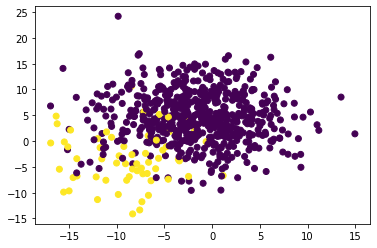

In [2]:
# Generate imbalanced dataset
X, y = make_blobs(n_samples=[600, 60], random_state=1, cluster_std=5)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [3]:
# Normal train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)
Counter(y_train)

Counter({0: 451, 1: 44})

## Random Oversampling

In [4]:
# implement random oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=1)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

Counter(y_resampled)

Counter({0: 451, 1: 451})

In [4]:
# An instance of RandomOverSampler is instantiated as ros.
# The training data (X_train and y_train) is resampled using the fit_resample() method.
# The results are called X_resampled and y_resampled.
# Counting the classes of the resampled target verifies that the minority class has been enlarged.

In [5]:
# Logistic regression using random oversampled data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs', random_state=1)
model.fit(X_resampled, y_resampled)

LogisticRegression(random_state=1)

In [6]:
# Display the confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[131,  18],
       [  1,  15]])

In [7]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, y_pred)

0.9083473154362416

In [8]:
# Print the imbalanced classification report
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.99      0.88      0.94      0.93      0.91      0.82       149
          1       0.45      0.94      0.88      0.61      0.91      0.83        16

avg / total       0.94      0.88      0.93      0.90      0.91      0.82       165



## SMOTE

In [5]:
# Synthetic Minority Oversampling Technique
# The synthetic minority oversampling technique (SMOTE) is another oversampling approach to deal with unbalanced datasets. In SMOTE, like random oversampling, the size of the minority is increased. The key difference between the two lies in how the minority class is increased in size. As we have seen, in random oversampling, instances from the minority class are randomly selected and added to the minority class. In SMOTE, by contrast, new instances are interpolated. That is, for an instance from the minority class, a number of its closest neighbors is chosen. Based on the values of these neighbors, new values are created.

In [9]:
from imblearn.over_sampling import SMOTE
X_resampled, y_resampled = SMOTE(random_state=1, sampling_strategy='auto').fit_resample(
    X_train, y_train
)
Counter(y_resampled)

Counter({0: 451, 1: 451})

In [6]:
# The sampling_strategy argument specifies how the dataset is resampled. By default, it increases the minority class size to equal the majority class's size.
# Again, the fit_resample() method is used on the training data to train the SMOTE model and to oversample in a single step.
# Counting the number of instances by class verifies that they are now equal in size

In [10]:
model = LogisticRegression(solver='lbfgs', random_state=1)
model.fit(X_resampled, y_resampled)

LogisticRegression(random_state=1)

In [11]:
# Calculated the balanced accuracy score
y_pred = model.predict(X_test)
balanced_accuracy_score(y_test, y_pred)

0.9150587248322148

In [12]:
# Display the confusion matrix
confusion_matrix(y_test, y_pred)

array([[133,  16],
       [  1,  15]])

In [13]:
# Print the imbalanced classification report
print(classification_report_imbalanced(y_test, y_pred))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.99      0.89      0.94      0.94      0.91      0.83       149
          1       0.48      0.94      0.89      0.64      0.91      0.84        16

avg / total       0.94      0.90      0.93      0.91      0.91      0.83       165



In [7]:
# The metrics of the minority class (precision, recall, and F1 score) are slightly improved over those of random oversampling.

# It's important to note that although SMOTE reduces the risk of oversampling, it does not always outperform random oversampling. 
# Another deficiency of SMOTE is its vulnerability to outliers. 
# We said earlier that a minority class instance is selected, and new values are generated based on its distance from its neighbors. 
# If the neighbors are extreme outliers, the new values will reflect this. 
# Finally, keep in mind that sampling techniques cannot overcome the deficiencies of the original dataset!